In [1]:
device = "cuda"

# Sample Weight Test

This notebook validates the `sample_weight` feature in PackBoost.

**Setup:** The training set has two regimes:
- **Early samples** (first ~70%): the true signal is buried in heavy noise — a weak version of the real relationship
- **Late samples** (last ~30%): clean signal identical to the val/test distribution

**Hypothesis:** a model trained with weights that upweight the late (clean) samples should learn the true relationship better than a model with uniform weights.

## 1. Setup — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from packboost.core import PackBoost
from packboost.callback import EarlyStoppingCallback

Installing kernels...


W0430 14:18:06.615000 131244 Lib\site-packages\torch\utils\cpp_extension.py:480] Error checking compiler version for cl: Command 'cl' returned non-zero exit status 2.


kernels successfully Installed!


## 2. Generate Training Data with Distribution Shift

The training set is split into two regimes:
- **Early 70k samples**: signal is dominated by "wrong" features (X[:,3], X[:,4]) + heavy noise
- **Late 30k samples**: signal matches val/test exactly (X[:,0], X[:,1], X[:,2] + light noise)

Val and test use only the true relationship.

In [3]:
np.random.seed(42)

N_early = 70_000   # noisy/wrong-feature samples
N_late  = 30_000   # clean samples matching val/test
N_train = N_early + N_late
N_val   = 2_000
N_test  = 500
N_feat  = 20

X_train = np.random.randint(0, 4, (N_train, N_feat), dtype='i1')
X_val   = np.random.randint(0, 4, (N_val,   N_feat), dtype='i1')
X_test  = np.random.randint(0, 4, (N_test,  N_feat), dtype='i1')

def make_y_true(X_):
    """True relationship (used by val, test, and late train samples)."""
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        + 0.22 * X_[:, 2].astype('f4')
        + 0.01 * np.random.randn(len(X_)).astype('f4')
    )

def make_y_noisy(X_):
    """Misleading relationship (early train): wrong features + high noise."""
    return (
        0.05 * X_[:, 0].astype('f4')          # true signal, but very weak
        + 0.40 * X_[:, 3].astype('f4')        # irrelevant feature, strong
        + 0.35 * X_[:, 4].astype('f4')        # irrelevant feature, strong
        + 0.25 * np.random.randn(len(X_)).astype('f4')  # heavy noise
    )

y_early = make_y_noisy(X_train[:N_early])
y_late  = make_y_true(X_train[N_early:])
y_train_raw = np.concatenate([y_early, y_late])

y_val_raw  = make_y_true(X_val)
y_test_raw = make_y_true(X_test)

print(f"Train shape : {X_train.shape}  (early={N_early}, late={N_late})")
print(f"Val shape   : {X_val.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"y_train range: [{y_train_raw.min():.3f}, {y_train_raw.max():.3f}]")

Train shape : (100000, 20)  (early=70000, late=30000)
Val shape   : (2000, 20)
Test shape  : (500, 20)
y_train range: [-0.906, 3.253]


## 3. Preprocess & Bucketize Targets

Scale all targets to [-0.5, 0.5] using the train scaler, then bucketize into 4 bins centered around 0.

In [4]:
scaler = MinMaxScaler(feature_range=(-0.5, 0.5))
y_train_scaled = scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_scaled   = scaler.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_scaled  = scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

bins   = [-0.5, -0.25, 0, 0.25, 0.5]
labels = [-0.375, -0.125, 0.125, 0.375]

def bucketize(y_scaled):
    return np.array(
        pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True),
        dtype=float
    ).astype(np.float32)

y_train = bucketize(y_train_scaled)
y_val   = bucketize(y_val_scaled)
y_test  = bucketize(y_test_scaled)

print(f"y_train unique: {np.unique(y_train)}")
print(f"y_val   unique: {np.unique(y_val)}")
print(f"y_test  unique: {np.unique(y_test)}")

y_train unique: [-0.375 -0.125  0.125  0.375]
y_val   unique: [-0.375 -0.125  0.125  0.375]
y_test  unique: [-0.375 -0.125  0.125  0.375]


## 4. Train — No Sample Weights (baseline)

In [5]:
# Base hyperparams shared by both runs.
# L2 and min_child_weight are calibrated for mean(w) = 1.
# The weighted run scales them by w_mean to keep regularisation equivalent.
BASE_KWARGS = dict(
    rounds=1000,
    max_depth=8,
    nfolds=4,
    lr=1.0,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device,
    min_split_gain=0.0,
)
L2_BASE         = 1_000.0   # regularisation at mean(w) = 1
MIN_CHILD_BASE  =   100.0   # min leaf hessian-mass at mean(w) = 1

FIT_KWARGS = dict(**BASE_KWARGS, L2=L2_BASE, min_child_weight=MIN_CHILD_BASE)

es_no_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_no_w = PackBoost(device=device)
t0 = time.time()
model_no_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
               callbacks=[es_no_w], **FIT_KWARGS)
print(f"No-weights training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_no_w.best_tree_set}, best val r={es_no_w.best_score:.4f})")

[Round 10] improved -> score=2.830947e-01
[Round 20] improved -> score=3.435978e-01
[Round 30] improved -> score=3.814989e-01
[Round 40] improved -> score=3.913979e-01
[Round 50] improved -> score=3.942003e-01
[Round 60] improved -> score=3.953353e-01
[Round 70] improved -> score=3.955920e-01
[Round 80] improved -> score=3.982217e-01
[Round 90] improved -> score=4.017761e-01
[Round 100] improved -> score=4.018151e-01
[Round 110] improved -> score=4.034939e-01
[Round 120] improved -> score=4.042493e-01
[Round 130] no improve 1/50 | 0.4042493498225346
[Round 140] improved -> score=4.074694e-01
[Round 150] improved -> score=4.076135e-01
[Round 160] improved -> score=4.078356e-01
[Round 170] improved -> score=4.082048e-01
[Round 180] improved -> score=4.090470e-01
[Round 190] improved -> score=4.094231e-01
[Round 200] no improve 1/50 | 0.4094230978799383
[Round 210] improved -> score=4.098491e-01
[Round 220] improved -> score=4.100170e-01
[Round 230] improved -> score=4.101803e-01
[Round 2

## 5. Train — With Sample Weights

Early samples receive weight **1**, late samples receive weight **10**.
This tells the model "the last 30k samples are 10x more representative of the true distribution."

In [6]:
# Early samples: w=1 (low trust)
# Late  samples: w=10 (high trust — match val/test distribution)
sample_weight = np.ones(N_train, dtype=np.float32)
sample_weight[N_early:] = 10.0

w_mean = float(sample_weight.mean())   # 3.7

print(f"Weight distribution: early={np.unique(sample_weight[:N_early])}, "
      f"late={np.unique(sample_weight[N_early:])}")
print(f"Effective sample count: early={sample_weight[:N_early].sum():.0f}, "
      f"late={sample_weight[N_early:].sum():.0f}")
print(f"w_mean={w_mean:.3f}")
print(f"  → L2={L2_BASE * w_mean:.0f}  (×w_mean)")
print(f"  → min_child_weight={MIN_CHILD_BASE * w_mean:.0f}  (×w_mean)")

# Scale L2/min_child_weight by w_mean for equivalent regularisation.
# Add max_delta_step to clip individual leaf values that would otherwise
# be ~w_max/w_mean = 2.7x too large due to gradient inflation.
FIT_KWARGS_W = dict(**BASE_KWARGS,
                    L2=L2_BASE * w_mean,
                    min_child_weight=MIN_CHILD_BASE * w_mean,
                    max_delta_step=50.0)

es_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_w = PackBoost(device=device)
t0 = time.time()
model_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
            sample_weight=sample_weight, callbacks=[es_w], **FIT_KWARGS_W)
print(f"Weighted training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_w.best_tree_set}, best val r={es_w.best_score:.4f})")

Weight distribution: early=[1.], late=[10.]
Effective sample count: early=70000, late=300000
w_mean=3.700
  → L2=3700  (×w_mean)
  → min_child_weight=370  (×w_mean)
[Round 10] improved -> score=6.993448e-01
[Round 20] improved -> score=7.565266e-01
[Round 30] improved -> score=7.877170e-01
[Round 40] improved -> score=8.071929e-01
[Round 50] improved -> score=8.229397e-01
[Round 60] improved -> score=8.322934e-01
[Round 70] improved -> score=8.391699e-01
[Round 80] improved -> score=8.443848e-01
[Round 90] improved -> score=8.502319e-01
[Round 100] improved -> score=8.535229e-01
[Round 110] improved -> score=8.560632e-01
[Round 120] improved -> score=8.578425e-01
[Round 130] improved -> score=8.610794e-01
[Round 140] improved -> score=8.642416e-01
[Round 150] improved -> score=8.655201e-01
[Round 160] improved -> score=8.666323e-01
[Round 170] improved -> score=8.677590e-01
[Round 180] improved -> score=8.682539e-01
[Round 190] improved -> score=8.690321e-01
[Round 200] improved -> sco

## 6b. Train — Fractional Weights (early=0.1, late=1.0)

Same 10:1 relative ratio as the previous run, but expressed as a **downweight** on old samples (0.1) rather than an upweight on new ones (10). This uses the new fractional weight support (1/1024 resolution).


In [13]:
# Fractional weights: old/noisy samples = 0.1, recent/clean samples = 1.0
# Same 10:1 ratio as the previous run, but expressed as a downweight instead of an upweight.
sample_weight_frac = np.ones(N_train, dtype=np.float32)
sample_weight_frac[:N_early] = 0.001

w_mean_frac = float(sample_weight_frac.mean())

print(f"Weight distribution: early={np.unique(sample_weight_frac[:N_early])}, "
      f"late={np.unique(sample_weight_frac[N_early:])}")
print(f"Effective sample count: early={sample_weight_frac[:N_early].sum():.1f}, "
      f"late={sample_weight_frac[N_early:].sum():.1f}")
print(f"w_mean={w_mean_frac:.3f}")
print(f"  → L2={L2_BASE * w_mean_frac:.1f}  (×w_mean)")
print(f"  → min_child_weight={MIN_CHILD_BASE * w_mean_frac:.1f}  (×w_mean)")

# L2 and min_child_weight scaled by w_mean for equivalent regularisation.
# No max_delta_step needed: downweighting old samples deflates (not inflates) leaf values.
FIT_KWARGS_FRAC = dict(**BASE_KWARGS,
                       L2=L2_BASE * w_mean_frac,
                       min_child_weight=MIN_CHILD_BASE * w_mean_frac)

es_frac = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_frac = PackBoost(device=device)
t0 = time.time()
model_frac.fit(X_train, y_train, Xv=X_val, Yv=y_val,
               sample_weight=sample_weight_frac, callbacks=[es_frac], **FIT_KWARGS_FRAC)
print(f"Fractional-weights training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_frac.best_tree_set}, best val r={es_frac.best_score:.4f})")


Weight distribution: early=[0.001], late=[1.]
Effective sample count: early=70.0, late=30000.0
w_mean=0.301
  → L2=300.7  (×w_mean)
  → min_child_weight=30.1  (×w_mean)
[Round 10] improved -> score=3.885898e-01
[Round 20] improved -> score=5.301428e-01
[Round 30] improved -> score=6.160516e-01
[Round 40] improved -> score=6.631457e-01
[Round 50] improved -> score=6.951397e-01
[Round 60] improved -> score=7.209622e-01
[Round 70] improved -> score=7.401818e-01
[Round 80] improved -> score=7.564552e-01
[Round 90] improved -> score=7.684062e-01
[Round 100] improved -> score=7.805393e-01
[Round 110] improved -> score=7.891955e-01
[Round 120] improved -> score=7.958873e-01
[Round 130] improved -> score=8.003142e-01
[Round 140] improved -> score=8.047706e-01
[Round 150] improved -> score=8.080079e-01
[Round 160] improved -> score=8.112676e-01
[Round 170] improved -> score=8.137592e-01
[Round 180] improved -> score=8.160630e-01
[Round 190] improved -> score=8.174616e-01
[Round 200] improved ->

## 6. Compare Metrics

In [8]:
def evaluate(model, X, y_true, label):
    preds = model.predict(X) / (1 << 30)
    r = np.corrcoef(preds, y_true)[0, 1]
    ss_res = np.sum((y_true - preds) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return {"model": label, "Pearson r": round(float(r), 4), "R²": round(float(r2), 4)}, preds

metrics_no_w,   preds_no_w   = evaluate(model_no_w,   X_test, y_test, "No weights")
metrics_w,      preds_w      = evaluate(model_w,       X_test, y_test, "Weights: late=10 (int)")
metrics_frac,   preds_frac   = evaluate(model_frac,    X_test, y_test, "Weights: early=0.1 (frac)")

results = pd.DataFrame([metrics_no_w, metrics_w, metrics_frac]).set_index("model")
print(results.to_string())
print()
base_r = metrics_no_w["Pearson r"]
for m in [metrics_w, metrics_frac]:
    print(f"{m['model']:35s}  Δr={m['Pearson r'] - base_r:+.4f}  ΔR²={m['R²'] - metrics_no_w['R²']:+.4f}")


                           Pearson r      R²
model                                       
No weights                    0.4641  0.1193
Weights: late=10 (int)        0.8525  0.7225
Weights: early=0.1 (frac)     0.8133  0.6578

Weights: late=10 (int)               Δr=+0.3884  ΔR²=+0.6032
Weights: early=0.1 (frac)            Δr=+0.3492  ΔR²=+0.5385


## 7. Visualize — True vs Predicted & Residuals

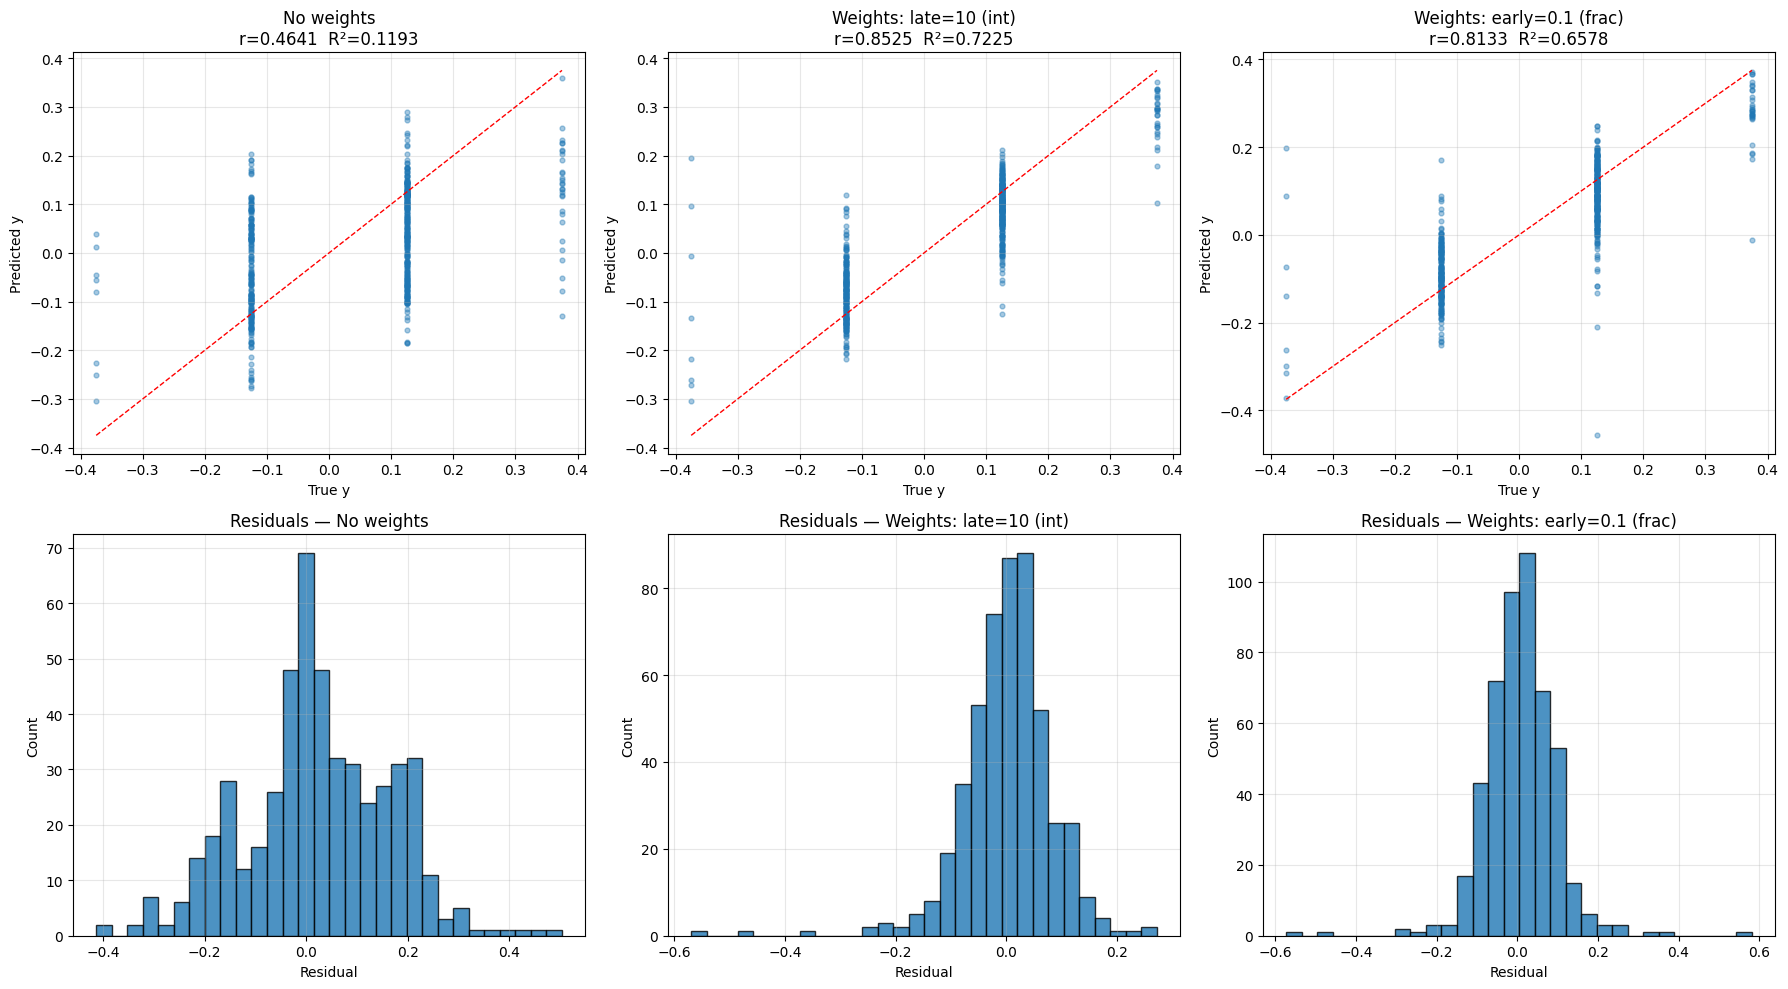

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

all_results = [
    (preds_no_w,  metrics_no_w),
    (preds_w,     metrics_w),
    (preds_frac,  metrics_frac),
]

for col, (preds, m) in enumerate(all_results):
    r, r2 = m["Pearson r"], m["R²"]
    label = m["model"]

    # scatter
    ax = axes[0, col]
    ax.scatter(y_test, preds, alpha=0.4, s=12)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")
    ax.set_title(f"{label}\nr={r:.4f}  R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

    # residuals
    ax = axes[1, col]
    ax.hist(y_test - preds, bins=30, edgecolor='black', alpha=0.8)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(f"Residuals — {label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
